In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
expression_df = pd.read_csv(
    "../data/raw/data.csv",
    index_col=0
)

labels_df = pd.read_csv(
    "../data/raw/labels.csv"
)

In [3]:
print("Expression Shape:", expression_df.shape)
print("Labels Shape:", labels_df.shape)

Expression Shape: (801, 20531)
Labels Shape: (801, 2)


In [4]:
gene_variances = expression_df.var()

In [5]:
top_20_variance = gene_variances.sort_values(ascending=False).head(20)

print(top_20_variance)

gene_9176     44.763849
gene_9175     36.361940
gene_15898    34.503915
gene_15301    33.458776
gene_15589    31.325845
gene_3540     30.587696
gene_19661    30.080478
gene_3541     28.721689
gene_11250    26.515887
gene_15897    26.019446
gene_439      24.907236
gene_8014     24.536552
gene_15896    23.948239
gene_4773     23.585390
gene_19236    22.273271
gene_16283    22.219048
gene_9177     22.175862
gene_3461     22.165311
gene_8891     21.995722
gene_2844     21.633754
dtype: float64


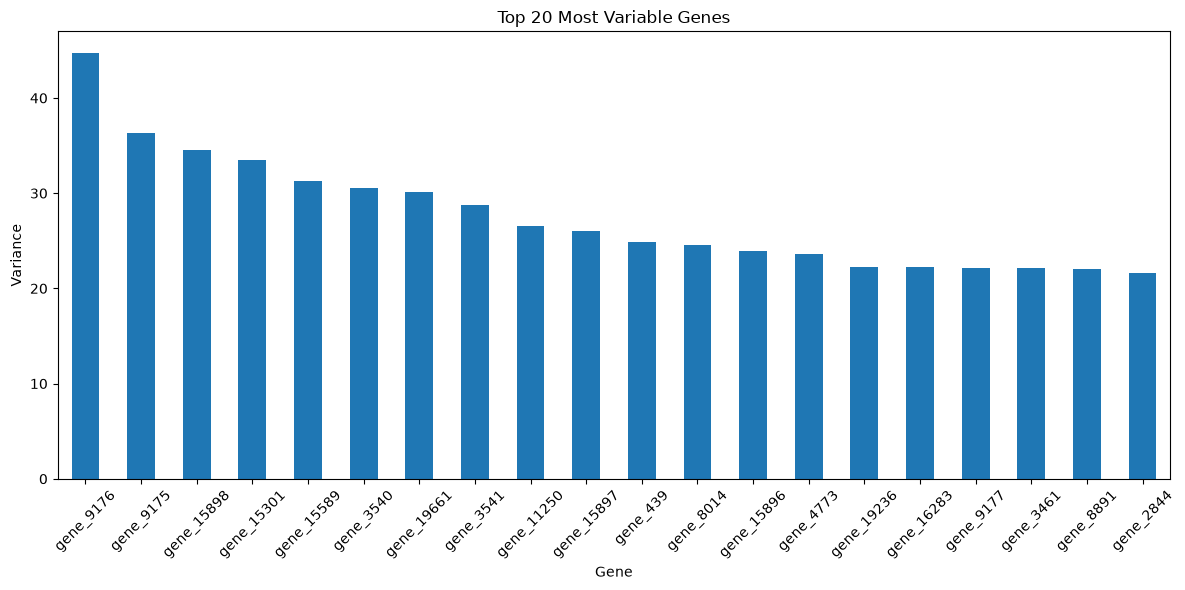

In [6]:
plt.figure(figsize=(12,6))

top_20_variance.plot(kind="bar")

plt.title("Top 20 Most Variable Genes")
plt.xlabel("Gene")
plt.ylabel("Variance")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [7]:
# Summary statistics of gene variances
print(gene_variances.describe())

count    20531.000000
mean         1.764138
std          2.574352
min          0.000000
25%          0.343816
50%          0.801383
75%          2.173090
max         44.763849
dtype: float64


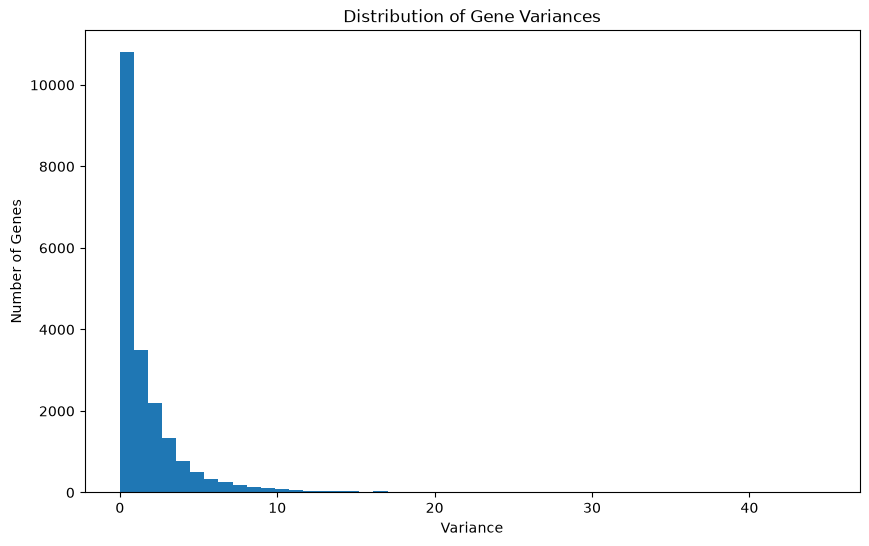

In [8]:
plt.figure(figsize=(10,6))

plt.hist(gene_variances, bins=50)

plt.title("Distribution of Gene Variances")

plt.xlabel("Variance")

plt.ylabel("Number of Genes")

plt.show()

In [9]:
print(gene_variances.describe())

count    20531.000000
mean         1.764138
std          2.574352
min          0.000000
25%          0.343816
50%          0.801383
75%          2.173090
max         44.763849
dtype: float64


In [10]:
variance_threshold = gene_variances.median()

selected_genes = gene_variances[
    gene_variances > variance_threshold
].index

filtered_expression_df = expression_df[selected_genes]

In [11]:
print("Original number of genes:")
print(expression_df.shape[1])

print("\nRemaining genes after variance filtering:")
print(filtered_expression_df.shape[1])

Original number of genes:
20531

Remaining genes after variance filtering:
10265


In [12]:
filtered_expression_df.to_csv(
    "../data/processed/variance_filtered_expression.csv"
)

print("Filtered dataset saved successfully!")

Filtered dataset saved successfully!
